In [25]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

from datasets import CirclesDataset, MoonsDataset, SpiralDataset, SwissRollDataset
from components.models import ANFISAdvanced, ANFISSimple, fcm_initialize

# Reproducibility helpers
torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [26]:
@dataclass
class TrainingSpec:
    task_type: str
    num_classes: int
    n_outputs: int


@dataclass
class PlotContext:
    X_train: np.ndarray
    y_train: np.ndarray
    X_test: np.ndarray
    y_test: np.ndarray
    base_point: np.ndarray
    task_type: str
    num_classes: int


def infer_training_spec(dataset, y_train: np.ndarray) -> TrainingSpec:
    task_type = getattr(dataset, "task_type", None)
    num_classes = getattr(dataset, "num_classes", None)

    if task_type is None:
        if np.issubdtype(y_train.dtype, np.floating):
            task_type = "regression"
        else:
            unique = np.unique(y_train)
            num_classes = len(unique)
            task_type = "binary_classification" if num_classes == 2 else "multiclass_classification"

    if "classification" in task_type and (num_classes is None or num_classes == 0):
        num_classes = len(np.unique(y_train))

    if task_type == "regression":
        num_classes = 0
        n_outputs = 1
    elif task_type == "binary_classification":
        num_classes = 2 if num_classes is None else int(num_classes)
        n_outputs = 1
    else:
        num_classes = int(num_classes)
        n_outputs = num_classes

    return TrainingSpec(task_type=task_type, num_classes=num_classes, n_outputs=n_outputs)


def prepare_targets(spec: TrainingSpec, y_train: np.ndarray, y_test: np.ndarray):
    if spec.task_type == "multiclass_classification":
        y_train_t = torch.tensor(y_train, dtype=torch.long, device=DEVICE)
        y_test_t = torch.tensor(y_test, dtype=torch.long, device=DEVICE)
    else:
        train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, spec.n_outputs)
        test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, spec.n_outputs)
        y_train_t = train.to(DEVICE)
        y_test_t = test.to(DEVICE)
    return y_train_t, y_test_t


def make_loss_fn(spec: TrainingSpec):
    if spec.task_type == "regression":
        return nn.MSELoss()
    if spec.task_type == "binary_classification":
        return nn.BCEWithLogitsLoss()
    return nn.CrossEntropyLoss()


def fit_model(
    name: str,
    model: nn.Module,
    loss_fn,
    optimizer,
    X_train_t: torch.Tensor,
    y_train_t: torch.Tensor,
    X_test_t: torch.Tensor,
    y_test_t: torch.Tensor,
    epochs: int,
):
    best_loss = float("inf")
    best_state = None
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)
        preds = model(X_train_t)
        loss = loss_fn(preds, y_train_t)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        with torch.no_grad():
            val_loss = loss_fn(model(X_test_t), y_test_t).item()
        history.append((loss.item(), val_loss))

        if val_loss < best_loss:
            best_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch == 1 or epoch % max(epochs // 5, 1) == 0:
            print(
                f"{name:<18} Epoch {epoch:4d}/{epochs} | "
                f"Train Loss: {loss.item():.4f} | Test Loss: {val_loss:.4f}"
            )

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    return model, history


def evaluate_metrics(model: nn.Module, X_t: torch.Tensor, y_t: torch.Tensor, spec: TrainingSpec):
    with torch.no_grad():
        logits = model(X_t)
        if spec.task_type == "regression":
            diff = logits - y_t
            rmse = torch.sqrt(torch.mean(diff ** 2)).item()
            return {"rmse": rmse}
        if spec.task_type == "binary_classification":
            prob = torch.sigmoid(logits).squeeze(1)
            targets = y_t.squeeze(1).long()
            preds = (prob >= 0.5).long()
        else:
            prob = torch.softmax(logits, dim=1)
            targets = y_t.long()
            preds = torch.argmax(prob, dim=1)

        correct = (preds == targets).sum().item()
        total = targets.numel()
        accuracy = correct / total
        return {
            "accuracy": accuracy,
            "error": 1.0 - accuracy,
            "correct": correct,
            "incorrect": total - correct,
        }


def format_metric_line(tag: str, spec: TrainingSpec, metrics: dict) -> str:
    if spec.task_type == "regression":
        return f"{tag} RMSE: {metrics['rmse']:.4f}"
    return (
        f"{tag} Accuracy: {metrics['accuracy'] * 100:.2f}% "
        f"| Error: {metrics['error'] * 100:.2f}% "
        f"(correct={metrics['correct']}, incorrect={metrics['incorrect']})"
    )


def get_rule_centers(model: nn.Module):
    mf_layer = getattr(model, "mf_layer", None)
    if mf_layer is None:
        return None
    if hasattr(mf_layer, "centers"):
        centers = mf_layer.centers.detach().cpu().numpy()
    elif hasattr(mf_layer, "c"):
        centers = mf_layer.c.detach().cpu().numpy()
    else:
        centers = None
    return centers


def plot_model(ax, model: nn.Module, model_name: str, ctx: PlotContext, resolution: int = 300):
    if ctx.X_train.shape[1] < 2:
        raise ValueError("Visualization requires at least two input features.")

    X_all = np.vstack((ctx.X_train, ctx.X_test))
    x_min, x_max = X_all[:, 0].min() - 0.5, X_all[:, 0].max() + 0.5
    y_min, y_max = X_all[:, 1].min() - 0.5, X_all[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution),
    )
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

    if ctx.base_point.shape[0] > 2:
        grid_full = np.tile(ctx.base_point, (grid.shape[0], 1)).astype(np.float32)
        grid_full[:, :2] = grid
    else:
        grid_full = grid

    grid_tensor = torch.from_numpy(grid_full).to(next(model.parameters()).device)
    model.eval()
    with torch.no_grad():
        logits = model(grid_tensor)

    if ctx.task_type == "regression":
        field = logits.detach().cpu().numpy().reshape(xx.shape)
        contour = ax.contourf(xx, yy, field, levels=40, cmap="viridis", alpha=0.8)
        ax.figure.colorbar(contour, ax=ax, label="Prediction")
    elif ctx.task_type == "binary_classification":
        prob = torch.sigmoid(logits).squeeze(1).cpu().numpy().reshape(xx.shape)
        contour = ax.contourf(xx, yy, prob, levels=30, cmap="RdBu_r", alpha=0.7)
        ax.figure.colorbar(contour, ax=ax, label="P(class=1)")
    else:
        preds = torch.argmax(logits, dim=1).cpu().numpy().reshape(xx.shape)
        cmap = plt.cm.get_cmap("tab10", max(ctx.num_classes, 2))
        contour = ax.contourf(xx, yy, preds, levels=ctx.num_classes, cmap=cmap, alpha=0.6)
        ax.figure.colorbar(contour, ax=ax, label="Predicted class")

    if ctx.task_type == "regression":
        scatter_cmap = "viridis"
        train_colors = ctx.y_train
        test_colors = ctx.y_test
    else:
        scatter_cmap = plt.cm.get_cmap("tab10", max(ctx.num_classes, 2))
        train_colors = ctx.y_train
        test_colors = ctx.y_test

    ax.scatter(
        ctx.X_train[:, 0],
        ctx.X_train[:, 1],
        c=train_colors,
        cmap=scatter_cmap,
        edgecolor="k",
        s=35,
        alpha=0.8,
        label="Train",
    )
    ax.scatter(
        ctx.X_test[:, 0],
        ctx.X_test[:, 1],
        c=test_colors,
        cmap=scatter_cmap,
        edgecolor="k",
        s=55,
        marker="^",
        alpha=0.9,
        label="Test",
    )

    centers = get_rule_centers(model)
    if centers is not None:
        ax.scatter(
            centers[:, 0],
            centers[:, 1],
            c="yellow",
            edgecolor="black",
            s=160,
            marker="X",
            label="Rule centers",
        )

    ax.set_title(model_name)
    ax.legend(loc="upper right")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")



In [27]:
# ---------------------------------------------
# 1) Choose dataset class & basic hyperparameters
# ---------------------------------------------
# Pick the dataset by instantiating the class you need (no string lookups required).
dataset = MoonsDataset()

N_RULES = 6
N_EPOCHS = 600
LEARNING_RATE = 1e-3
ADVANCED_S_MODE = "alpha_beta"  # "alpha_beta" or "C" for Gaussian+sigmoid blending

X_train, X_test, y_train, y_test = dataset.numpy()
spec = infer_training_spec(dataset, y_train)

print(f"Using dataset: {dataset.__class__.__name__}")
print(f"Task type: {spec.task_type}")
if "classification" in spec.task_type:
    print(f"Number of classes: {spec.num_classes}")
print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")

X_train_t = torch.from_numpy(X_train).to(DEVICE)
X_test_t = torch.from_numpy(X_test).to(DEVICE)
y_train_t, y_test_t = prepare_targets(spec, y_train, y_test)

plot_ctx = PlotContext(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    base_point=np.mean(np.vstack((X_train, X_test)), axis=0).astype(np.float32),
    task_type=spec.task_type,
    num_classes=spec.num_classes,
)



Using dataset: MoonsDataset
Task type: binary_classification
Number of classes: 2
Train samples: 1600 | Test samples: 400


In [28]:
# ---------------------------------------------
# 2) Initialize rules with FCM + build both ANFIS variants
# ---------------------------------------------
centers_init, spreads_init = fcm_initialize(X_train, N_RULES)
centers_init = centers_init.astype(np.float32)
spreads_init = spreads_init.astype(np.float32)
print(f"Initialized {N_RULES} rule centers via FCM.")

loss_fn = make_loss_fn(spec)
print(
    "Using loss:"
    f" {'MSE' if spec.task_type == 'regression' else ('BCEWithLogits' if spec.task_type == 'binary_classification' else 'CrossEntropy')}"
)

models_info = []
model_builders = [
    (
        "Simple ANFIS",
        lambda: ANFISSimple(centers_init.copy(), spreads_init.copy(), n_outputs=spec.n_outputs),
    ),
    (
        "Advanced ANFIS",
        lambda: ANFISAdvanced(
            centers_init.copy(),
            spreads_init.copy(),
            n_outputs=spec.n_outputs,
            s_mode=ADVANCED_S_MODE,
        ),
    ),
]

for name, builder in model_builders:
    model = builder().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    trained_model, history = fit_model(
        name,
        model,
        loss_fn,
        optimizer,
        X_train_t,
        y_train_t,
        X_test_t,
        y_test_t,
        epochs=N_EPOCHS,
    )
    models_info.append({"name": name, "model": trained_model, "history": history})



Initialized 6 rule centers via FCM.
Using loss: BCEWithLogits
Simple ANFIS       Epoch    1/600 | Train Loss: 0.6956 | Test Loss: 0.6956
Simple ANFIS       Epoch  120/600 | Train Loss: 0.6248 | Test Loss: 0.6233
Simple ANFIS       Epoch  240/600 | Train Loss: 0.5556 | Test Loss: 0.5528
Simple ANFIS       Epoch  360/600 | Train Loss: 0.4820 | Test Loss: 0.4787
Simple ANFIS       Epoch  480/600 | Train Loss: 0.4020 | Test Loss: 0.4020
Simple ANFIS       Epoch  600/600 | Train Loss: 0.3275 | Test Loss: 0.3329
Advanced ANFIS     Epoch    1/600 | Train Loss: 0.6933 | Test Loss: 0.6930
Advanced ANFIS     Epoch  120/600 | Train Loss: 0.6250 | Test Loss: 0.6236
Advanced ANFIS     Epoch  240/600 | Train Loss: 0.5583 | Test Loss: 0.5554
Advanced ANFIS     Epoch  360/600 | Train Loss: 0.4926 | Test Loss: 0.4878
Advanced ANFIS     Epoch  480/600 | Train Loss: 0.4294 | Test Loss: 0.4234
Advanced ANFIS     Epoch  600/600 | Train Loss: 0.3742 | Test Loss: 0.3685


In [29]:
# ---------------------------------------------
# 3) Report metrics (accuracy/error counts or RMSE)
# ---------------------------------------------
for info in models_info:
    model = info["model"]
    train_metrics = evaluate_metrics(model, X_train_t, y_train_t, spec)
    test_metrics = evaluate_metrics(model, X_test_t, y_test_t, spec)
    with torch.no_grad():
        test_loss = loss_fn(model(X_test_t), y_test_t).item()

    header = f"\n{info['name']}\n{'-' * len(info['name'])}"
    print(header)
    print(format_metric_line("Train", spec, train_metrics))
    print(format_metric_line("Test ", spec, test_metrics))
    if spec.task_type == "regression":
        print(f"Test loss (MSE): {test_loss:.4f}")
    elif spec.task_type == "binary_classification":
        print(f"Test loss (BCEWithLogits): {test_loss:.4f}")
    else:
        print(f"Test loss (CrossEntropy): {test_loss:.4f}")




Simple ANFIS
------------
Train Accuracy: 93.19% | Error: 6.81% (correct=1491, incorrect=109)
Test  Accuracy: 92.75% | Error: 7.25% (correct=371, incorrect=29)
Test loss (BCEWithLogits): 0.3329

Advanced ANFIS
--------------
Train Accuracy: 87.88% | Error: 12.12% (correct=1406, incorrect=194)
Test  Accuracy: 89.00% | Error: 11.00% (correct=356, incorrect=44)
Test loss (BCEWithLogits): 0.3685


/tmp/ipykernel_120159/3620710790.py:205: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  scatter_cmap = plt.cm.get_cmap("tab10", max(ctx.num_classes, 2))


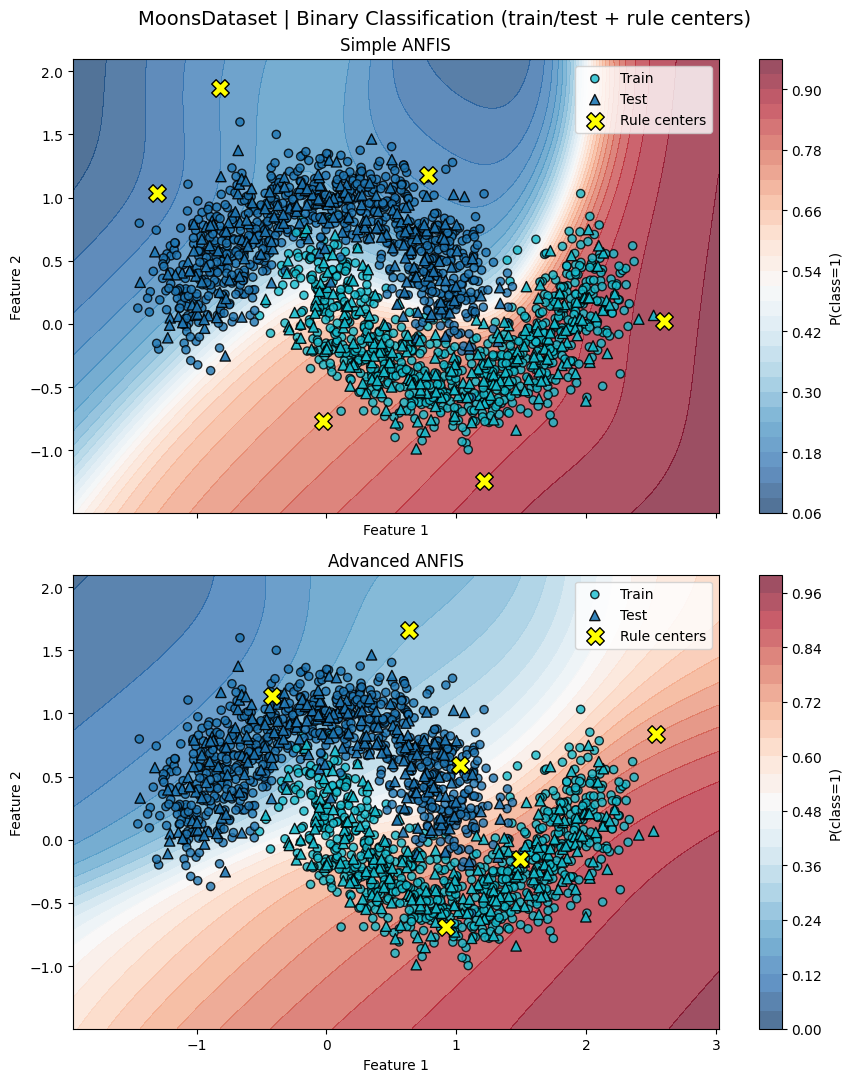

In [30]:
# ---------------------------------------------
# 4) Decision surfaces + rule centers
# ---------------------------------------------
fig, axes = plt.subplots(len(models_info), 1, figsize=(9, 11), sharex=True, sharey=True)
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

for ax, info in zip(axes, models_info):
    plot_model(ax, info["model"], info["name"], plot_ctx)

fig.suptitle(
    f"{dataset.__class__.__name__} | {spec.task_type.replace('_', ' ').title()} (train/test + rule centers)",
    fontsize=14,
)
plt.tight_layout()
plt.show()

